# Correlation of POP2 Predictions for Round 2

In [145]:
import pandas as pd
# pop2_preds = pd.read_csv('notebooks/jacob/results/r1_ethyvalerolactam_predicted_activity.csv')
pop2_preds = pd.read_csv('notebooks/jacob/results/r1_ethyvalerolactam_stacked_predicted_activity.csv')
# pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_predicted_activity.csv')
# pop2_preds = pd.read_csv('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_20members_predicted_activity.csv')
pop2_preds = pop2_preds.set_index('seq_id')
model_columns = [c for c in pop2_preds.columns if c.startswith('model_')]
pop2_preds[model_columns] = pop2_preds[model_columns].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

In [146]:
BETA = 1.0

pop2_preds['has_F61'] = pop2_preds.index.str.contains('F61')
pop2_preds['mean'] = pop2_preds[model_columns].mean(axis=1)
pop2_preds['stddev'] = pop2_preds[model_columns].std(axis=1)
pop2_preds['score'] = pop2_preds['mean'] + BETA * pop2_preds['stddev']

pop2_preds = pop2_preds.sort_values('score', ascending=False)


In [147]:
import torch
import pandas as pd
from botorch.models.ensemble import EnsembleModel
from torch import Tensor
from botorch.acquisition import qUpperConfidenceBound
from botorch.optim import optimize_acqf_discrete

# pop2_df: index = seq_id, columns = model_1 … model_20 (float scores)
QUCB_BETA  = 4.0                      # exploration weight – tune as you like
Q     = 24                      # slate size

pop2_subset = pop2_preds[model_columns].head(10000).sample(frac=1.0)

N, S = pop2_subset.shape          # N ≈ 20 000 ; S = 20 models
assert S == len(model_columns), "Expect one column per model"

# tensor shape  (S, N)  == (ensemble, candidates)
pred_tensor = torch.tensor(pop2_preds[model_columns].values.T, dtype=torch.float32)  # (20, N)
seq_ids     = pop2_preds[model_columns].index.to_numpy()                             # (N,)
choices = torch.arange(N, dtype=torch.long).unsqueeze(-1)   # (N, 1)


class PrecomputedEnsemble(EnsembleModel):
    def __init__(self, preds: Tensor):
        """
        preds : (S, N)   where S = # models (20) and N = # sequences
        """
        super().__init__()
        self.register_buffer("preds", preds)   # not trainable
        self._num_outputs = 1                  # tells BoTorch that m = 1

    def forward(self, X: Tensor) -> Tensor:
        """
        Parameters:
        X (Tensor) - A batch_shape x n x d-dim input tensor X.

        Returns
        :
        A batch_shape x s x n x m-dimensional output tensor where s is the size of the ensemble.
        """
        # print(f'X.shape: {X.shape}, expect batch_shape x q (24) x 1')
        idx = X.long().squeeze(-1)             # (..., q)
        out = self.preds[:, idx]               # (S, ..., q)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        out = out.movedim(0, 1)               # (..., S, q)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        out = out.unsqueeze(-1)               # (..., S, q, 1)
        # print(f'out.shape: {out.shape}, want batch_shape x ensemble_size x q (24) x 1')
        return out

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device('cpu')

model = PrecomputedEnsemble(pred_tensor.to(device)).eval()
acqf  = qUpperConfidenceBound(model=model, beta=QUCB_BETA)

cands, _ = optimize_acqf_discrete(
    acq_function   = acqf,
    choices        = choices.to(device),   # (N, 1)
    q              = Q,
    # sequential     = True,                 # greedy but uses X_pending
    max_batch_size = 2048                  # avoid CUDA OOM
)


KeyboardInterrupt: 

In [94]:
QUCB_BETA = 3.0    # UCB exploration weight
Q         = 24     # slate size

# pop2_df: index = seq_id, columns = model_1 … model_20 (float scores)
pop2_subset = pop2_preds[model_columns].head(1000)
pred_tensor = torch.tensor(
    pop2_subset.values.T, dtype=torch.float32
)  # (S, N) = (ensemble, candidates)
seq_ids = pop2_subset.index.to_numpy()  # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns)

# compute prior means, deviations, and full covariance
means = pred_tensor.mean(dim=0)          # (N,)
devs  = pred_tensor - means              # (S, N)
# sample‐covariance matrix (N×N):
Cov   = (devs.T @ devs) / S              # (N, N)
vars  = Cov.diag()                       # (N,)

# greedy Kriging‐Believer slate selection (see https://www.cs.ubc.ca/labs/algorithms/EARG/stack/2010_CI_Ginsbourger-ParallelKriging.pdf)
selected = []

for _ in range(Q):
    # 1) marginal UCB scores
    ucb = means + QUCB_BETA * vars.sqrt()        # (N,)
    if selected:
        ucb[selected] = -float("inf")            # mask out already‐picked

    # 2) pick best
    idx = int(ucb.argmax().item())
    selected.append(idx)

    # 3) fantasy‐conditioning where you imagine that you pick that sequence: Schur complement to zero covariances with idx (same as covariance thing i wrote a bit back)
    cov_i = Cov[:, idx].clone()                  # (N,)
    v_i   = vars[idx].item()                     # scalar Var(x_idx)
    # Cov_new = Cov - (cov_i outer cov_i) / Var_i
    Cov   = Cov - cov_i.unsqueeze(1) * cov_i.unsqueeze(0) / v_i
    vars  = Cov.diag()                           # update variances

#  map back to your sequence IDs
chosen_seq_ids = seq_ids[selected]               # length Q
print("Chosen slate (seq_ids):", chosen_seq_ids)

Chosen slate (seq_ids): ['G429R_R512E' 'M320R_G429R' 'H8K_G429R' 'Y405R_G429R' 'H8K_Q237E'
 'H8R_G429R' 'G255R_G429R' 'M320R_T390R' 'H8Q_G429R' 'G429R_T473E'
 'E251P_G429R' 'E42R_G429R' 'S336R_G429R' 'D46R_G429R' 'E251R_G429R'
 'D321P_G429R' 'M320G_G429R' 'E251N_G429R' 'G429R_A506P' 'Q237E_R512E'
 'F316R_G429R' 'S57R_G429R' 'G429R_P435R' 'E251K_G429R']


# Constant Liar

In [148]:
import torch

# --- Constants and data setup ---
QUCB_BETA = 1.0    # UCB exploration weight
Q         = 24     # slate size
TAU2      = 1e-3   # Variance floor for numerical stability
KRIGING_BELIEVER = True

# pop2_preds: DataFrame indexed by seq_id, cols = model_1 … model_20
subset_df = pop2_preds.sort_values('score', ascending=False)[model_columns].head(10000)
pred_tensor  = torch.tensor(subset_df.values.T, dtype=torch.float32)  # (S, N)
seq_ids      = subset_df.index.to_numpy()                             # (N,)

S, N = pred_tensor.shape
assert S == len(model_columns), "Expect one column per model"

# means, deviations, and full covariance 
means = pred_tensor.mean(dim=0)          # (N,)
devs  = pred_tensor - means              # (S, N)
Cov   = (devs.T @ devs) / S              # (N, N)
vars  = Cov.diag().clamp_min(TAU2)       # (N,)
sigmas = vars.sqrt()                     # (N,)

# constant liar setup: choose L as the ****minimum**** prior mean 
# very adversarial
# L = means.mean().item()
L = means.min().item()

# greedy Constant Liar batch‐UCB selection 
selected = []

for ii in range(Q):
    # 1) compute marginal UCB scores with current means and variances
    ucb = means + QUCB_BETA * sigmas
    ucb[selected] = -float("inf")  # mask out already‐picked

    # 2) select best candidate
    idx = int(ucb.argmax().item())
    selected.append(idx)
    print(f'Selecting {seq_ids[idx]} with UCB: {ucb[idx]} = {means[idx]} + {QUCB_BETA} * {sigmas[idx]}')

    if KRIGING_BELIEVER and ii == 0:
        L = means[idx]

    # 3) "lie" by imagining a ***bad*** constant observation y = L at idx:
    cov_i = Cov[:, idx].clone()        # (N,)
    v_i   = vars[idx].item()           # Var at idx

    

    # 4) update posterior means conditional on fake bad y=L
    #     μ_new = μ + cov_i * (L - μ[idx]) / v_i
    last_mean = means[idx]
    means = means + cov_i * (L - means[idx]) / (v_i + TAU2)

    if KRIGING_BELIEVER:
        L = last_mean
    # if any(means > 1000):
    #     problem_indices = torch.where(means > 100)[0]
    #     print(f'means: {means[problem_indices[0]]}')
    #     print(f'cov_i: {cov_i[problem_indices[0]]}')
    #     print(f'v_i: {v_i}')
    #     print(f'L: {L}')

    # 5) update covariance via Schur complement, same as KG believer
    Cov   = Cov - torch.outer(cov_i, cov_i) / (v_i + TAU2)
    Cov    = 0.5 * (Cov + Cov.T)         # re-symmetrise
    vars  = Cov.diag().clamp_min(TAU2)
    sigmas = vars.sqrt()                # update std devs

# map back to sequence IDs 
constant_liar_chosen_seq_ids = seq_ids[selected]     # length Q
print("Constant Liar UCB slate:", constant_liar_chosen_seq_ids)

Selecting F80A_Y81A with UCB: 3.0214195251464844 = 2.5265767574310303 + 1.0 * 0.49484267830848694
Selecting P53I_F80A with UCB: 3.2853822708129883 = 3.1056907176971436 + 1.0 * 0.17969149351119995
Selecting F80D_Y255T with UCB: 7.931103229522705 = 7.8270063400268555 + 1.0 * 0.10409677773714066
Selecting M1C_F80A with UCB: 14.19814395904541 = 13.454126358032227 + 1.0 * 0.7440172433853149
Selecting F80A_R145F with UCB: 12.349323272705078 = 12.04110336303711 + 1.0 * 0.3082194924354553
Selecting L59H_F80A with UCB: 3.340801239013672 = 3.309178352355957 + 1.0 * 0.03162277862429619
Selecting F80A_G206S with UCB: 2.9002397060394287 = 2.868616819381714 + 1.0 * 0.03162277862429619
Selecting F80C_F287R with UCB: 2.866943359375 = 2.835320472717285 + 1.0 * 0.03162277862429619
Selecting F80A_F287R with UCB: 2.8135502338409424 = 2.7819273471832275 + 1.0 * 0.03162277862429619
Selecting F80A_G206C with UCB: 2.776319742202759 = 2.744696855545044 + 1.0 * 0.03162277862429619
Selecting F80A_L263K with UCB:

In [149]:
tmp = pop2_preds.reset_index()
tmp[tmp.seq_id.isin(constant_liar_chosen_seq_ids)]

,seq_id,model_0,model_1,model_2,model_3,model_4,relevant_measured_mutants,has_F61,mean,stddev,score
0,F80A_Y81A,1.968116,1.940688,2.864906,2.674733,3.184441,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.526577,0.553251,3.079828
1,F80A_G206C,2.756142,2.725675,2.620973,3.104706,2.974913,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.836482,0.197664,3.034146
2,F80A_L263K,2.565961,2.812176,2.595182,2.747057,2.972371,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.738549,0.166213,2.904762
3,F80A_G206I,2.733653,2.504740,2.487278,2.917091,2.863914,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.701335,0.199058,2.900394
5,F80A_F287R,2.821802,2.741313,2.938710,2.781399,2.816180,"F287W, F287W, F80A, F80A, F80C, F80C, F80S, F80S",False,2.819881,0.073810,2.893691
6,F80A_G206Q,2.569827,2.714557,2.493351,2.863106,2.915137,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.711196,0.181743,2.892939
10,F80A_G206S,2.453517,2.672838,2.305966,2.939103,2.628403,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.599965,0.239278,2.839243
11,F80A_F287K,2.703139,2.629935,2.739273,2.717000,2.888551,"F287W, F287W, F80A, F80A, F80C, F80C, F80S, F80S",False,2.735579,0.094832,2.830411
14,F80A_G206Y,2.635718,2.535169,2.435788,2.749252,2.875416,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.646269,0.173112,2.819380
16,F80A_L263R,2.513047,2.627617,2.585720,2.690353,2.878520,"F80A, F80A, F80C, F80C, F80S, F80S",False,2.659052,0.138590,2.797642


In [150]:
tmp = pop2_preds.reset_index()
tmp[tmp.has_F61]

,seq_id,model_0,model_1,model_2,model_3,model_4,relevant_measured_mutants,has_F61,mean,stddev,score


In [157]:
selection_df = pd.concat([
    pop2_preds.iloc[:24]
    # pop2_preds[pop2_preds.index.isin(constant_liar_chosen_seq_ids)],
    # pop2_preds[pop2_preds.index.isin(['E110A'])],
    # pop2_preds.head(30),
    # pop2_preds.iloc[[63]],
    # pop2_preds.iloc[[64]]
    # pop2_preds[pop2_preds.has_F61].head(30)
])

selection_df.relevant_measured_mutants.value_counts()

relevant_measured_mutants
F80A, F80A, F80C, F80C, F80S, F80S                  20
F287W, F287W, F80A, F80A, F80C, F80C, F80S, F80S     3
F80A, F80A, F80C, F80C, F80S, F80S, N258S, N258S     1
Name: count, dtype: int64

In [158]:

import plotly.express as px

# Calculate correlation matrix

corr_matrix = selection_df[model_columns].T.corr()

# Create interactive heatmap
fig = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu_r', height=800, zmin=0, zmax=1)
fig.update_layout(title=f'Covariance Matrix Heatmap (Beta={BETA})')
fig.show()

In [169]:
import json
with open('notebooks/jacob/results/E250522_stacked_pairdropout_300epoch_debug_info.json', 'r') as f:
    debug_info = json.load(f)

In [170]:
df = pd.DataFrame()
for model_idx, model in enumerate(debug_info['finetune_metrics']):
    df = pd.concat([
        df,
        pd.DataFrame({
            'model': model_idx,
            'val_loss': model['val_loss'],
            'epoch': range(len(model['val_loss']))
        })
    ])

<Axes: xlabel='epoch', ylabel='val_loss'>

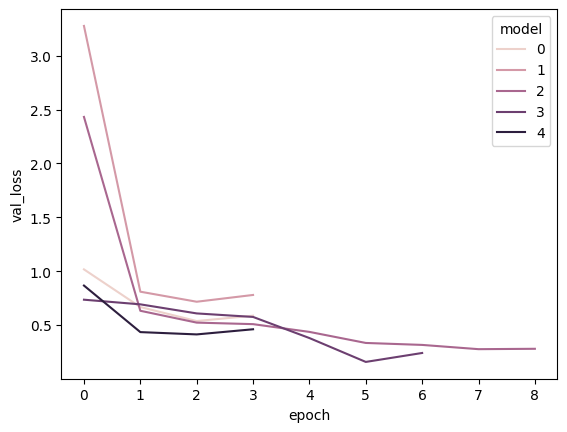

In [171]:
import seaborn as sns
sns.lineplot(
    data=df,
    x='epoch',
    y='val_loss',
    hue='model'
)

# qUCB

In [194]:
cands

tensor([[   3],
        [  15],
        [1657],
        [   1],
        [  64],
        [ 267],
        [  45],
        [  49],
        [5805],
        [ 338],
        [4288],
        [4960],
        [ 133],
        [ 406],
        [  11],
        [  63],
        [3296],
        [   0],
        [   2],
        [   4],
        [   5],
        [   6],
        [   7],
        [   8]])

In [151]:
pred_tensor = model.forward(cands)

In [152]:

mu  = pred_tensor.mean(0)                 # (N,)
std = pred_tensor.std(0)                  # (N,)
print(mu[:10], std[:10])
print("μ range:", float(mu.min()), float(mu.max()))
print("σ range:", float(std.min()), float(std.max()))

tensor([[ 4.1753],
        [12.9594],
        [ 5.5276],
        [ 7.9526],
        [ 9.8725]]) tensor([[1.6107],
        [1.5074],
        [0.9913],
        [0.7069],
        [1.2206]])
μ range: 4.175261974334717 12.959370613098145
σ range: 0.706923246383667 1.6106536388397217
